# GW Tensor Power Spectrum from VFDM — Transfer Function Approach

This notebook computes the GW energy density spectrum $\Omega_{\rm GW}h^2$ using the transfer function infrastructure.
A single CLASS run per mass gives $h_+(k,\tau_0)$ and $dh_+(k,\tau_0)$ on the full internal $k$-grid.

In [1]:
from classy import Class
import numpy as np
import json
from matplotlib import pyplot as plt

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
#%matplotlib widget

## Cosmological Parameters

In [7]:
# Planck 2018 Cosmological parameters
h_planck = 0.6688
omega_cdm = 0.1206
omega_b = 0.02212
tau_reio = 0.05522
As = 2.092e-9
ns = 0.962
r = 0.036

# Conversion factors and reference scales
MpctoHzfactor = 9.7e-15
factoreVtoMpc = 1.56e29
kj26 = 0.0594
kj25 = 0.184
kj24 = 0.581
aeq = 2.9e-4
keq = 0.0067

# VFDM parameters
frac = 1 - 1.e-6
#frac = 0.1
gamma_Ak = np.pi / 2

colors = ["#6d5a7a", "#365071", "#b66576", "#ebac8b", "#8a9a7b"]
colors_detector = ['#4F81BD', '#92B252', '#C0504D', '#D6B656', '#7172AE', '#25D13C']

# Precision overrides (previously hard-coded in include/precisions.h, now set per-notebook)
precision_settings = {
    'tol_thermo_integration': 1.0e-5,
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-7,
    'k_per_decade_primordial': 30.0,
}

## Helper Functions

In [ ]:
def Omega_GW(k, h_dot):
    """GW energy density spectrum Omega_GW h^2."""
    c_light = 3e5  # km/s
    H0 = 67 / c_light  # H0 in 1/Mpc
    kp = 0.05
    return (2*np.pi)**3 * As * (k/kp)**(ns-1) * h_dot**2 / (48 * np.pi**3 * H0**2)

def Omega_GW_LCDM(k, h_dot, nt=0., r=0.036):
    """GW energy density spectrum Omega_GW h^2."""
    c_light = 3e5  # km/s
    H0 = 67 / c_light  # H0 in 1/Mpc
    kp = 0.05
    return (2*np.pi)**3 * r * As * (k/kp)**(nt) * h_dot**2 / (48 * np.pi**3 * H0**2)

def Omega_GW_detector(freq, hc):
    H0 = 2.27e-18  # H0 in Hz
    return 2/3. * np.pi**2 * hc**2 * freq**2 / H0**2 / 0.67**2

def Omega_GW_COBE(freq):
    H0 = 2.27e-18
    return 7.e-11 * (H0/freq)**2 / 0.67**2

def Omega_GW_CMB_inflation(freq):
    """Inflationary GW background (arXiv:2004.11396)."""
    Omega_rad = 9.e-5
    f_eq = 2.27e-18 * 0.31 / np.sqrt(Omega_rad)
    f_cmb = 0.05 * MpctoHzfactor / (2*np.pi)
    nt = -r / 8.
    Omega_CMB = 3./128. * r * As * Omega_rad
    return Omega_CMB * (freq/f_cmb)**nt * (0.5*(f_eq/freq)**2 + 16./9.)

# Inflationary background
f_CMB = np.logspace(-18, -1, 400)
Omega_CMB = Omega_GW_CMB_inflation(f_CMB)


def run_vfdm_transfer(mass, frac, gamma_Ak, k_max=10.):
    """Run CLASS once and return (k, h+, dh+) from transfer functions."""
    cosmo = Class()
    cosmo.set({
        'h': h_planck,
        'omega_b': omega_b,
        'Omega_cdm': omega_cdm * (1-frac) / h_planck**2,
        'N_ncdm': 0.,
        'Omega_fld': 0.,
        'Omega_vf': frac * omega_cdm / h_planck**2,
        'attractor_ic_vf': 'yes',
        'svt_coupling': 'yes',
        'vf_tuning_index': 3,
        'vector_background_mode': 'bianchi',
        'YHe': 'BBN',
        'tau_reio': tau_reio,
        'output': 'tCl,pCl,dTk,mPk',
        'ic': 'ad',
        'gauge': 'synchronous',
        'A_s': As,
        'n_s': ns,
        'modes': 's',
        'gamma_Ak': gamma_Ak,
        'recombination': 'RECFAST',
        'vf_parameters': '%s, 1.e-16, 1.e-30, 0.01' % mass,
        'P_k_max_h/Mpc': k_max,
        'k_scalar_step_sub': 0.01,         # internal: k_step_sub, default 0.05
        'k_scalar_step_super': 0.001,      # internal: k_step_super, default 0.002
        'k_per_decade_for_bao' : 500.,
        'k_scalar_k_per_decade_for_pk': 500.,  # internal: k_per_decade_for_pk
        'k_per_decade_for_pk' : 500.,
        'tol_perturbations_integration': 1.e-8  # internal: tol_perturbations_integration, default 1.e-5
    })
    cosmo.set(precision_settings)
    cosmo.compute()

    
    transfer = cosmo.get_transfer(z=0)
    k = transfer['k (h/Mpc)'] * h_planck  # convert to 1/Mpc
    h_plus = transfer['h_+']
    dh_plus = transfer['dh_+']
    
    cosmo.empty()
    return k, h_plus, dh_plus

def run_lcdm_transfer(k_max=1.):
    """Run CLASS in pure LCDM and return (k, h+, dh+) for the free GW transfer function."""
    cosmo = Class()
    cosmo.set({
        'h': h_planck,
        'omega_b': omega_b,
        'Omega_cdm': omega_cdm / h_planck**2,   # full CDM, no VF
        'N_ncdm': 0.,
        'Omega_fld': 0.,
        'Omega_vf': 0.,
        'YHe': 'BBN',
        'tau_reio': tau_reio,
        'output': 'tCl,pCl,dTk,mPk',
        'ic': 'ad',
        'gauge': 'synchronous',
        'A_s': As,
        'n_s': ns,
        'modes': 's',
        'recombination': 'RECFAST',
        'compute_lcdm_tensor': 'yes',
        'P_k_max_h/Mpc': k_max,
        'k_scalar_step_sub': 0.01,
        'k_scalar_step_super': 0.001,
        'k_per_decade_for_bao' : 500.,
        'k_scalar_k_per_decade_for_pk': 500,
        'k_per_decade_for_pk' : 500.,
        'tol_perturbations_integration': 1.e-8
    })
    cosmo.set(precision_settings)
    cosmo.compute()

    transfer = cosmo.get_transfer(z=0)
    k = transfer['k (h/Mpc)'] * h_planck   # convert to 1/Mpc
    h_plus  = transfer['h_+']
    dh_plus = transfer['dh_+']

    cosmo.empty()
    return k, h_plus, dh_plus

## Compute Spectra (one CLASS run per mass)

In [ ]:
k_max = 100.  # h/Mpc

print(r'Running $\Lambda$CDM ...')
k_lcdm_s, h_lcdm_s, dh_lcdm_s = run_lcdm_transfer(k_max)

np.savez('../../PS_tensor/h+_LCDM_s_transfer', k=k_lcdm_s, h=h_lcdm_s)
np.savez('../../PS_tensor/dh+_LCDM_s_transfer', k=k_lcdm_s, hdot=dh_lcdm_s)

Running $\Lambda$CDM ...
Running $\Lambda$CDM with proper tensors ...


In [ ]:
# Load LCDM
h_lcdm_s_file = np.load('../../PS_tensor/h+_LCDM_s_transfer.npz')
dh_lcdm_s_file = np.load('../../PS_tensor/dh+_LCDM_s_transfer.npz')
k_lcdm_s, h_lcdm_s, dh_lcdm_s = h_lcdm_s_file['k'], h_lcdm_s_file['h'], dh_lcdm_s_file['hdot']

# LOAD SPECTRA
frac = 0.999999  # or whatever frac you used

# Load
data = {}
for mass_exp in [-24, -25, -26]:
    h_file = np.load('../../PS_tensor/h+_frac=%s_m=%d_gamma=pi2_transfer.npz' % (str(frac), mass_exp))
    dh_file = np.load('../../PS_tensor/dh+_frac=%s_m=%d_gamma=pi2_transfer.npz' % (str(frac), mass_exp))
    data[mass_exp] = {'k': h_file['k'], 'h': h_file['h'], 'dh': dh_file['hdot']}

k_24, dh_24 = data[-24]['k'], data[-24]['dh']
k_25, dh_25 = data[-25]['k'], data[-25]['dh']
k_26, dh_26 = data[-26]['k'], data[-26]['dh']

# Convert to frequency and Omega_GW
f_lcdm_s = MpctoHzfactor * k_lcdm_s
f_24 = MpctoHzfactor * k_24
f_25 = MpctoHzfactor * k_25
f_26 = MpctoHzfactor * k_26

Omega_lcdm_s = Omega_GW_LCDM(k_lcdm_s, dh_lcdm_s)
Omega_24 = Omega_GW(k_24, dh_24)
Omega_25 = Omega_GW(k_25, dh_25)
Omega_26 = Omega_GW(k_26, dh_26)

## Load Detector Sensitivity Curves

In [10]:
with open('../../detectors/SKA.json', 'r') as f:
    arr_SKA = np.array(json.load(f)['data'])
with open('../../detectors/LISA.json', 'r') as f:
    arr_LISA = np.array(json.load(f)['data'])
with open('../../detectors/EPTA.json', 'r') as f:
    arr_EPTA = np.array(json.load(f)['data'])
with open('../../detectors/LIGO.json', 'r') as f:
    arr_LIGO = np.array(json.load(f)['data'])
with open('../../detectors/BBO.json', 'r') as f:
    arr_BBO = np.array(json.load(f)['data'])

## Full GW Spectrum with Detectors

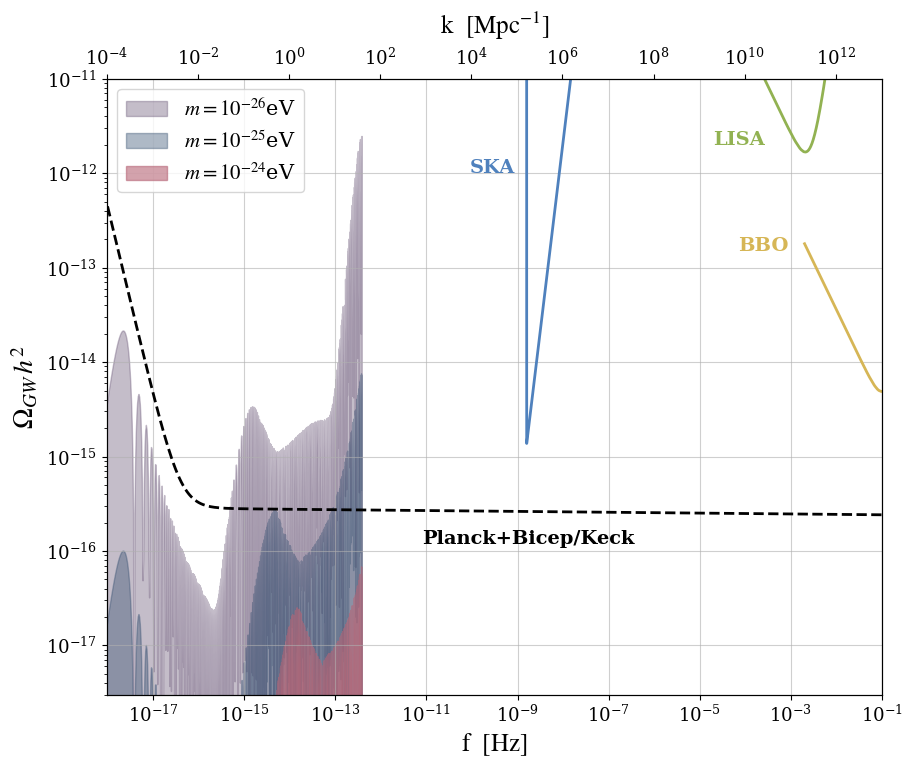

In [ ]:
# Inflationary background
f_CMB = np.logspace(-18, -1, 400)
f_planck = np.logspace(-18, np.log10(1.e-2 * MpctoHzfactor), 400)
Omega_CMB = Omega_GW_CMB_inflation(f_CMB)
Omega_planck = Omega_GW_CMB_inflation(f_planck)

plt.figure(figsize=(10, 8))

# VFDM spectra
plt.fill_between(f_26, Omega_26, color=colors[0], alpha=0.4, label=r'$m=10^{-26}$eV')
plt.fill_between(f_25, Omega_25, color=colors[1], alpha=0.4, label=r'$m=10^{-25}$eV')
plt.fill_between(f_24, Omega_24, color=colors[2], alpha=0.6, label=r'$m=10^{-24}$eV')

#plt.plot(f_lcdm_s, Omega_lcdm_s, 'k', alpha=0.5, label=r'$\Lambda$CDM - $r=0.036$')

# Inflationary background
plt.loglog(f_CMB, Omega_CMB, color='black', ls='--', lw=2)
#plt.loglog(f_planck, Omega_planck, color=colors_detector[5], lw=2)

# Detectors
plt.plot(arr_SKA[12:,0], Omega_GW_detector(arr_SKA[12:,0], arr_SKA[12:,1]),
         color=colors_detector[0], lw=2)
plt.plot(arr_LISA[:,0], Omega_GW_detector(arr_LISA[:,0], arr_LISA[:,1]),
         color=colors_detector[1], lw=2)
plt.plot(arr_EPTA[10:,0], Omega_GW_detector(arr_EPTA[10:,0], arr_EPTA[10:,1]),
         color=colors_detector[2], lw=2)
plt.plot(arr_BBO[:,0], Omega_GW_detector(arr_BBO[:,0], arr_BBO[:,1]),
         color=colors_detector[3], lw=2)

# Labels
plt.text(9e-11, 1e-12, 'SKA', color=colors_detector[0], fontsize=14, fontweight='bold')
plt.text(2e-5, 2e-12, 'LISA', color=colors_detector[1], fontsize=14, fontweight='bold')
#plt.text(4e-11, 3e-10, 'EPTA', color=colors_detector[2], fontsize=14, fontweight='bold')
plt.text(7e-5, 15e-14, 'BBO', color=colors_detector[3], fontsize=14, fontweight='bold')
#plt.text(3.e-18, 8.e-14, 'Planck+Bicep/Keck', color=colors_detector[5], fontsize=14, fontweight='bold')
plt.text(8e-12, 1.2e-16, 'Planck+Bicep/Keck', color='black', fontsize=14, fontweight='bold')
#plt.text(5e-9, 1.2e-16, r'$r=%s$'%r, color='black', fontsize=16, fontweight='bold')

plt.xlabel(r'f  [$\rm{Hz}$]', size=18, family='STIXGeneral')
plt.ylabel(r'$\Omega_{GW}\, h^2$', size=20, family='STIXGeneral')
plt.tick_params(axis='both', labelsize=13)
plt.legend(fontsize=15)
plt.xlim(MpctoHzfactor * 1e-4, 1e-1)
plt.ylim(3e-18, 1e-11)
plt.grid(True, alpha=0.6)
ax1 = plt.gca()
ax2 = ax1.twiny()
ax2.set_xscale('log')
ax2.set_xlim(np.array(ax1.get_xlim()) / MpctoHzfactor)
ax2.set_xlabel(r'k  [$\rm{Mpc}^{-1}$]', size=18, family='STIXGeneral', labelpad=10)
ax2.tick_params(axis='x', labelsize=13)
plt.savefig('../../Figures/GW_spectrum_frac=%s.pdf'%str(frac), format='pdf')
plt.savefig('../../Figures/GW_spectrum_frac=%s.png'%str(frac), format='png')
plt.show()